In [1]:
!pip install scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# Show first 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Data types
print("\nData Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (15509, 10)

Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


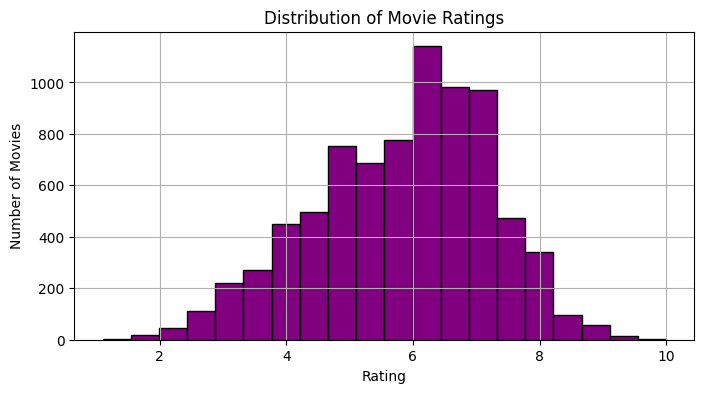

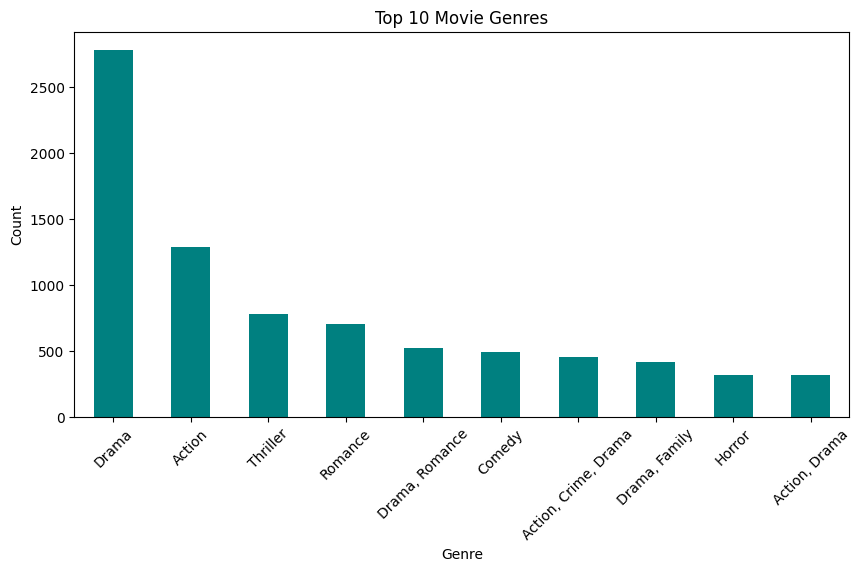

/tmp/ipykernel_554/606709795.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Rating', data=df_top, palette='Set2')


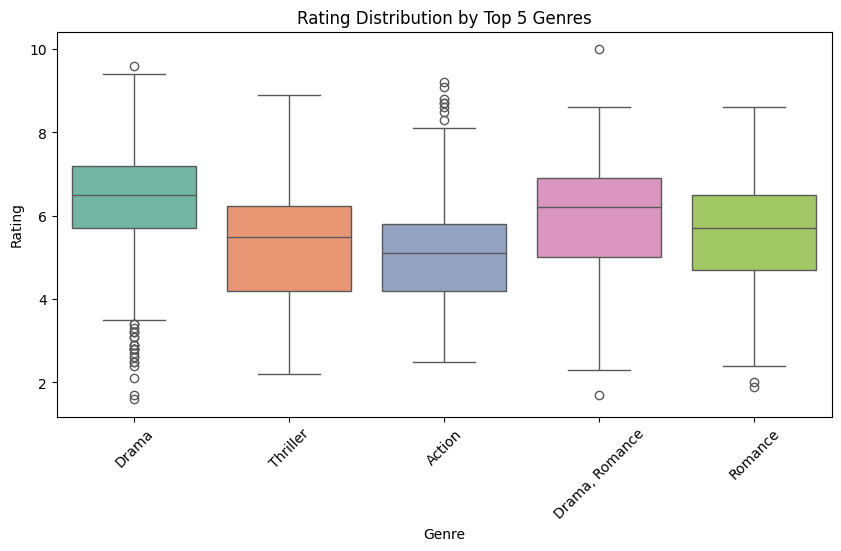

In [4]:
# Chart 1: Distribution of Movie Ratings
plt.figure(figsize=(8,4))
df['Rating'].dropna().hist(bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()

# Chart 2: Top 10 Genres
plt.figure(figsize=(10,5))
df['Genre'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Chart 3: Ratings by Genre (top 5 genres)
top_genres = df['Genre'].value_counts().head(5).index
df_top = df[df['Genre'].isin(top_genres)]
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Rating', data=df_top, palette='Set2')
plt.title('Rating Distribution by Top 5 Genres')
plt.xticks(rotation=45)
plt.show()

In [5]:
# Make a copy of the dataframe
df_clean = df.copy()

# Clean the 'Year' column - remove brackets like (2020)
df_clean['Year'] = df_clean['Year'].astype(str).str.extract('(\d{4})')
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')

# Clean the 'Duration' column - remove 'min' text
df_clean['Duration'] = df_clean['Duration'].astype(str).str.extract('(\d+)')
df_clean['Duration'] = pd.to_numeric(df_clean['Duration'], errors='coerce')

# Clean the 'Votes' column - remove commas
df_clean['Votes'] = df_clean['Votes'].astype(str).str.replace(',', '')
df_clean['Votes'] = pd.to_numeric(df_clean['Votes'], errors='coerce')

# Drop rows where Rating is missing (that's what we want to predict)
df_clean.dropna(subset=['Rating'], inplace=True)

# Fill remaining missing values
df_clean['Year'].fillna(df_clean['Year'].median(), inplace=True)
df_clean['Duration'].fillna(df_clean['Duration'].median(), inplace=True)
df_clean['Votes'].fillna(df_clean['Votes'].median(), inplace=True)
df_clean['Genre'].fillna('Unknown', inplace=True)
df_clean['Director'].fillna('Unknown', inplace=True)
df_clean['Actor 1'].fillna('Unknown', inplace=True)
df_clean['Actor 2'].fillna('Unknown', inplace=True)
df_clean['Actor 3'].fillna('Unknown', inplace=True)

print("✅ Data cleaned!")
print("Remaining rows:", df_clean.shape[0])
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

✅ Data cleaned!
Remaining rows: 7919

Missing values after cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_554/3409992176.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_clean['Year'] = df_clean['Year'].astype(str).str.extract('(\d{4})')
/tmp/ipykernel_554/3409992176.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_clean['Duration'] = df_clean['Duration'].astype(str).str.extract('(\d+)')
/tmp/ipykernel_554/3409992176.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead

In [6]:
# We use LabelEncoder to convert text columns to numbers
le = LabelEncoder()

# Encode categorical columns
df_clean['Genre_encoded'] = le.fit_transform(df_clean['Genre'])
df_clean['Director_encoded'] = le.fit_transform(df_clean['Director'])
df_clean['Actor1_encoded'] = le.fit_transform(df_clean['Actor 1'])
df_clean['Actor2_encoded'] = le.fit_transform(df_clean['Actor 2'])
df_clean['Actor3_encoded'] = le.fit_transform(df_clean['Actor 3'])

# Select features for the model
features = ['Year', 'Duration', 'Votes',
            'Genre_encoded', 'Director_encoded',
            'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']

X = df_clean[features]
y = df_clean['Rating']

print("✅ Features prepared!")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Features prepared!
X shape: (7919, 8)
y shape: (7919,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("✅ Data split done!")

Training samples: 6335
Testing samples: 1584
✅ Data split done!


In [8]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
print("📊 Linear Regression Results:")
print(f"MAE  (Mean Absolute Error): {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"RMSE (Root Mean Sq Error) : {np.sqrt(mean_squared_error(y_test, lr_pred)):.3f}")
print(f"R²   (Accuracy Score)     : {r2_score(y_test, lr_pred):.3f}")

📊 Linear Regression Results:
MAE  (Mean Absolute Error): 1.031
RMSE (Root Mean Sq Error) : 1.293
R²   (Accuracy Score)     : 0.101


In [9]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
print("📊 Random Forest Results:")
print(f"MAE  (Mean Absolute Error): {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"RMSE (Root Mean Sq Error) : {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f}")
print(f"R²   (Accuracy Score)     : {r2_score(y_test, rf_pred):.3f}")

📊 Random Forest Results:
MAE  (Mean Absolute Error): 0.832
RMSE (Root Mean Sq Error) : 1.101
R²   (Accuracy Score)     : 0.348


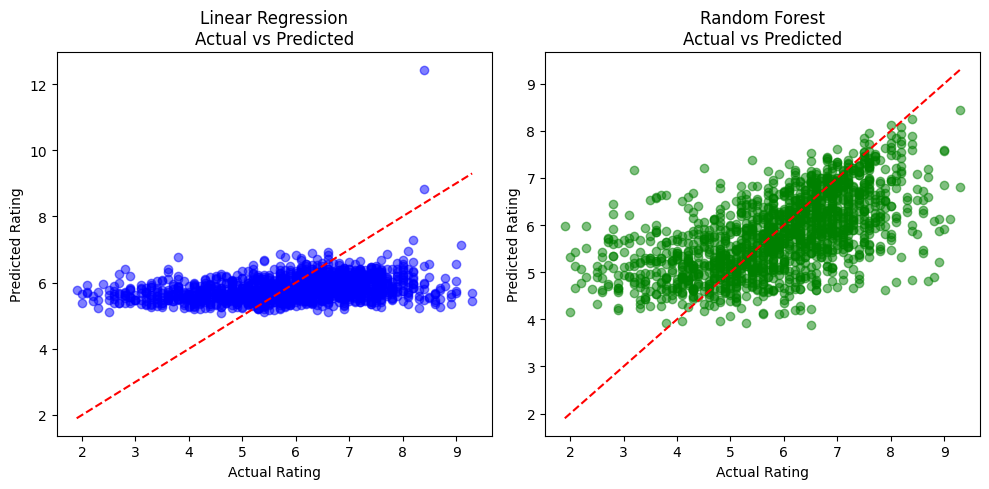

✅ The closer points are to the red line, the better the model!


In [10]:
# Compare actual vs predicted ratings
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(y_test, lr_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression\nActual vs Predicted')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')

plt.subplot(1,2,2)
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest\nActual vs Predicted')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')

plt.tight_layout()
plt.show()

print("✅ The closer points are to the red line, the better the model!")

/tmp/ipykernel_554/2780223354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


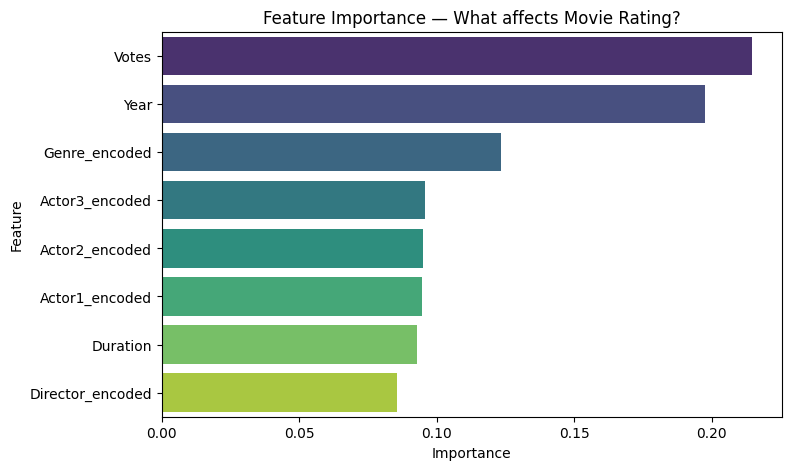

            Feature  Importance
2             Votes    0.214849
0              Year    0.197783
3     Genre_encoded    0.123458
7    Actor3_encoded    0.095717
6    Actor2_encoded    0.095036
5    Actor1_encoded    0.094654
1          Duration    0.092992
4  Director_encoded    0.085511


In [11]:
# Which features matter most?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance — What affects Movie Rating?')
plt.show()

print(importance)

In [12]:
# Predict rating for a hypothetical new movie
# Format: [Year, Duration, Votes, Genre_enc, Director_enc, Actor1_enc, Actor2_enc, Actor3_enc]

new_movie = pd.DataFrame([[2020, 130, 5000, 5, 100, 200, 300, 400]],
                          columns=features)

predicted_rating = rf_model.predict(new_movie)
print(f"🎬 Predicted Movie Rating: {predicted_rating[0]:.1f} / 10")

🎬 Predicted Movie Rating: 5.2 / 10


In [13]:
print("=" * 45)
print("        MODEL COMPARISON SUMMARY")
print("=" * 45)
print(f"Linear Regression R² : {r2_score(y_test, lr_pred):.3f}")
print(f"Random Forest R²     : {r2_score(y_test, rf_pred):.3f}")
print("=" * 45)

if r2_score(y_test, rf_pred) > r2_score(y_test, lr_pred):
    print("🏆 Random Forest is the BETTER model!")
else:
    print("🏆 Linear Regression is the BETTER model!")

        MODEL COMPARISON SUMMARY
Linear Regression R² : 0.101
Random Forest R²     : 0.348
🏆 Random Forest is the BETTER model!
